# Simulation study

Before proceeding with the main tasks, make sure to complete the initial setting by running the following code.

In [1]:
import os 
import numpy as np
from joblib import Parallel,delayed
import matplotlib.pyplot as plt
from package import *
rc('text', usetex=True)
rc('font', family='serif')
sz = 32
save_path = os.getcwd() + '\\' + 'image' + '\\' + 'simulation'+ '\\'
save_data_path = os.getcwd() + '\\' + 'data' + '\\' + 'synthesis'+ '\\'

### Convergence rate of paramaters

In simulation part, we will set repeat_time = 300.

In [2]:
repeat_time = 1 ### set 300
n = [200,400,600,800,1000]
v = [1,-0.5,0]

In [3]:
def simulation(n, N, v, m_lower, m_upper,
                name = 'NURHM',
                repeat_time = 10,
                ):
    current_dir = os.getcwd()
    data_dir = current_dir + '\\' +'data' + '\\' + 'synthesis' + '\\'

    d = len(v)
    for nn in n:
        for _ in range(repeat_time):
            print('-'*10)
            H = MultipleComparison(nn,N,v,m_lower=m_lower,m_upper=m_upper,Type = name)
            u_true, v_true = H.u,H.v
            u_estimation, v_estimation = AM(H.T,H.X,nn,d,u_initial=u_true,v_initial=v_true)
            u_infty = max(abs(u_estimation-u_true))
            v_infty = max(abs(v_estimation-v_true))
            print(f'n:{nn},u_infty:{u_infty},v_infty:{v_infty}')
            with open(data_dir+name+'.txt', 'a') as file:
                file.write(str(nn) + ',' + str(u_infty) + ',' + str(v_infty) + '\n')

##### NURHM

In [4]:

N = lambda n: int(0.1*n*(np.log(n))**3)
m_lower = 2
m_upper = 8
simulation(n, N, v, m_lower, m_upper, repeat_time = repeat_time,name = 'NURHM')

----------
complete get edges: Num_Edges=2974, Num_Nodes = 200,m_lower = 2,m_upper = 8
n:200,u_infty:0.6526350633621614,v_infty:0.030266037288020575
----------
complete get edges: Num_Edges=8603, Num_Nodes = 400,m_lower = 2,m_upper = 8
n:400,u_infty:0.5060717548115181,v_infty:0.026149965997953162
----------
complete get edges: Num_Edges=15706, Num_Nodes = 600,m_lower = 2,m_upper = 8
n:600,u_infty:0.4663558619847269,v_infty:0.007749448188507424
----------
complete get edges: Num_Edges=23895, Num_Nodes = 800,m_lower = 2,m_upper = 8
n:800,u_infty:0.4669607872892929,v_infty:0.021373130411001418
----------
complete get edges: Num_Edges=32961, Num_Nodes = 1000,m_lower = 2,m_upper = 8
n:1000,u_infty:0.4064025983130204,v_infty:0.00810984549973548


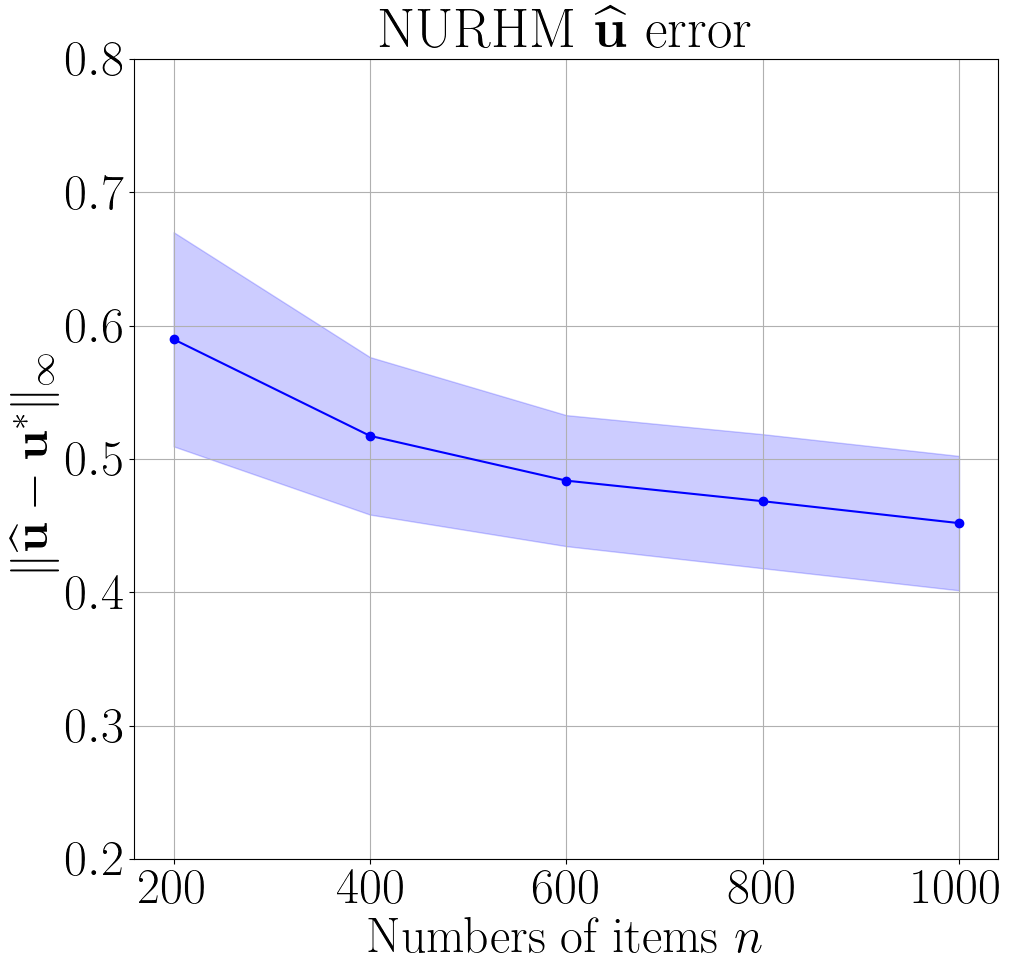

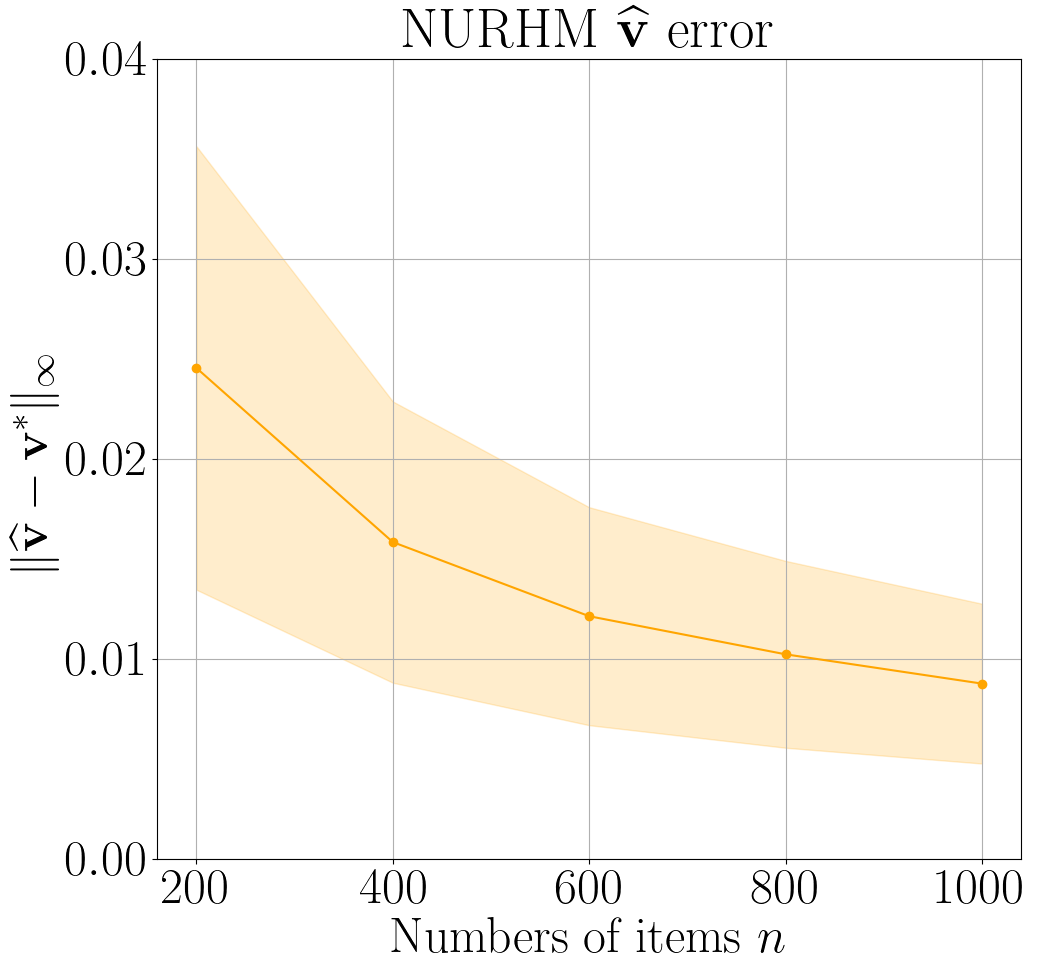

In [5]:
basicfun.plot('NURHM',save_path)

##### HSBM

In [12]:
N = lambda n: int(0.07*n**2)
m_lower = 5
m_upper = 6
simulation(n, N, v, m_lower, m_upper, repeat_time = repeat_time,name = 'HSBM')

----------
complete get edges: Num_Edges=2800, Num_Nodes = 200,m_lower = 5,m_upper = 6
[156, 72, 107, 186, 158]
n:200,u_infty:0.5913925399860573,v_infty:0.014452078783052713
----------
complete get edges: Num_Edges=11200, Num_Nodes = 400,m_lower = 5,m_upper = 6
[127, 131, 74, 51, 9]
n:400,u_infty:0.47170631504131205,v_infty:0.01570277793708974
----------
complete get edges: Num_Edges=25200, Num_Nodes = 600,m_lower = 5,m_upper = 6
[411, 545, 532, 304, 491]
n:600,u_infty:0.3867108911804379,v_infty:0.006219436671387246
----------
complete get edges: Num_Edges=44800, Num_Nodes = 800,m_lower = 5,m_upper = 6
[152, 39, 265, 109, 197]
n:800,u_infty:0.35861311847370164,v_infty:0.003323270179605754
----------
complete get edges: Num_Edges=70000, Num_Nodes = 1000,m_lower = 5,m_upper = 6
[694, 855, 914, 416, 708]
n:1000,u_infty:0.3327136760794098,v_infty:0.0065334089721502675


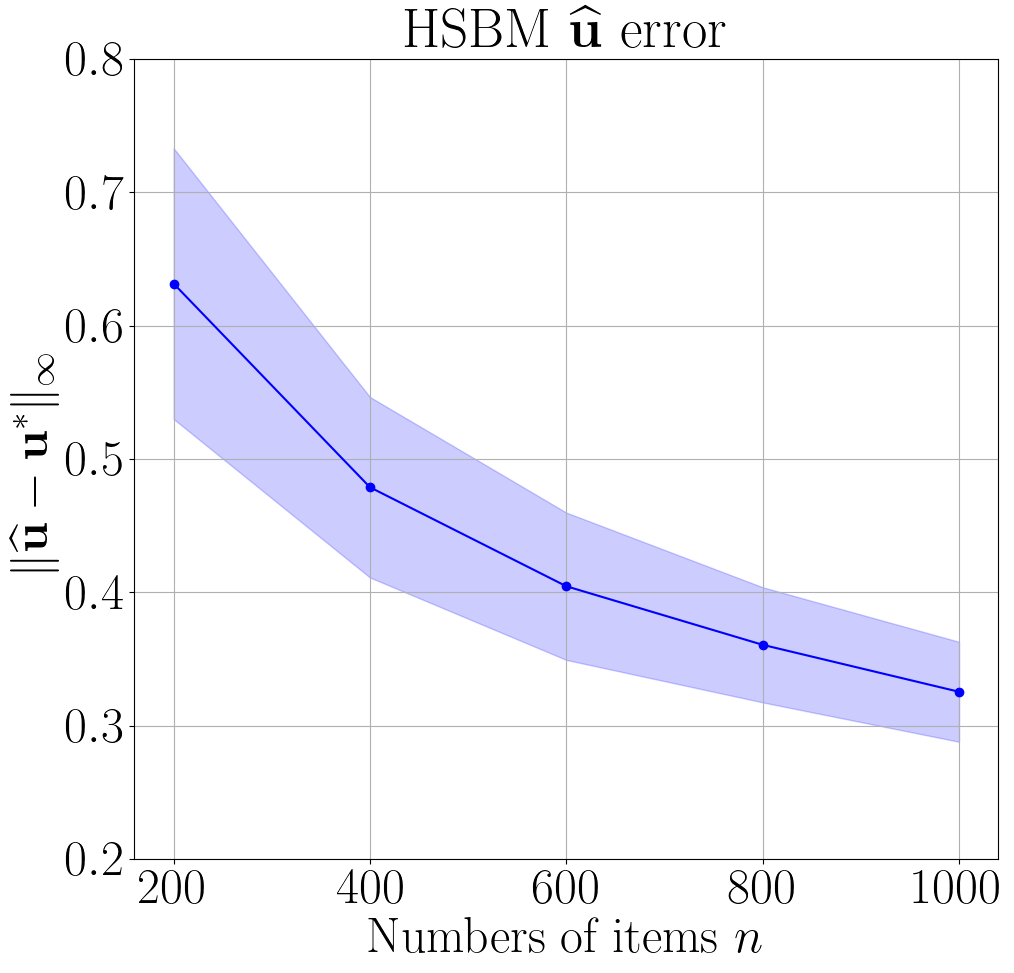

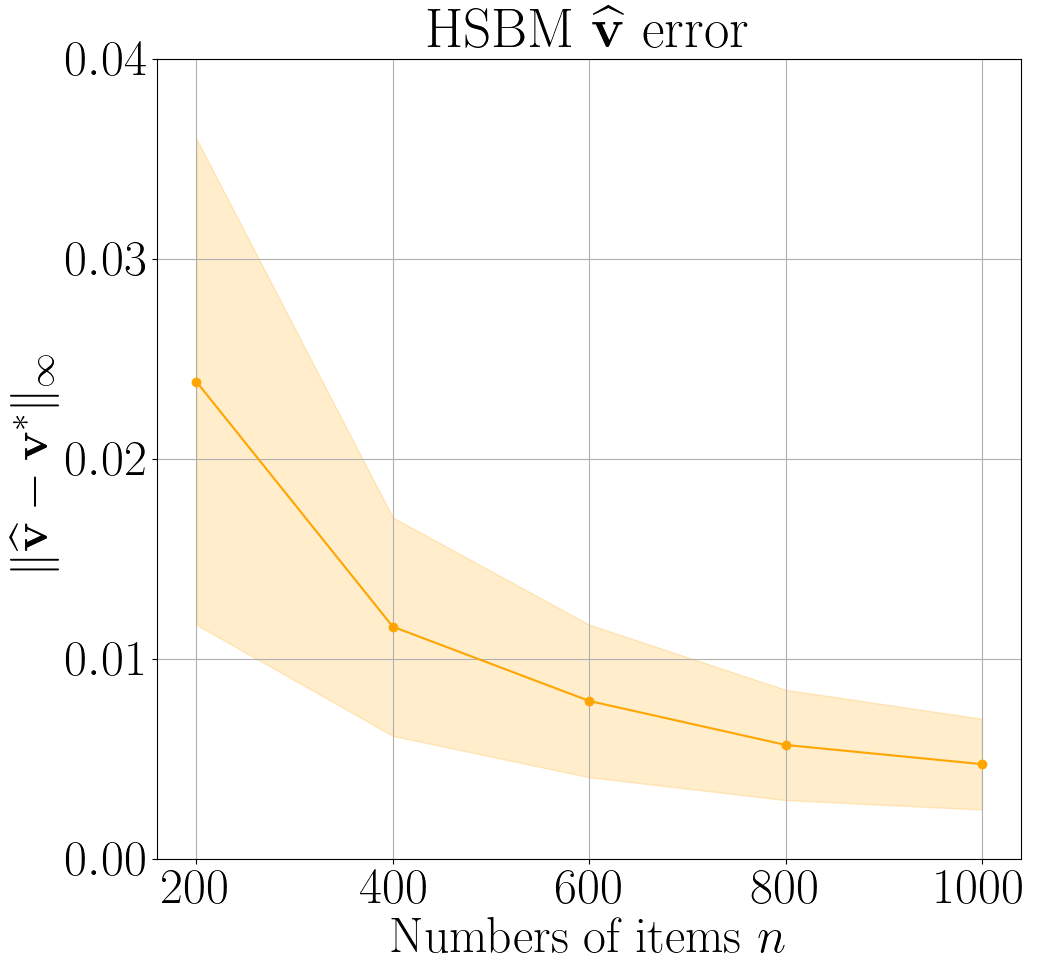

In [13]:
basicfun.plot('HSBM',save_path)

### Convergence rate of alternating maximization algorithm

In [2]:
def x_generator(x):
    m, d = x.shape
    variables = np.random.normal(x,0.5,size=(m,d))
    return variables
def test(n,N,v,d,error = 1e-16,x_generator = x_generator):
    
    H = generator.MultipleComparison(n,N,v,
                                 x_center = lambda n,d:np.random.normal(0,1,(n,d)),
                                 x_generator = x_generator
                                 ,m_lower=2,m_upper=3)
    T,K = H.T,H.X 
    L = algorithm.pair_alternative(T,K,n,d,E=error,Eu=error,Ev=error, I = 1500,save_likelihood=True)
    return {f'{n},{N(n)}':L}

In [2]:
error = 1e-16
v = [0.5,-0.2]
d = len(v)
m_lower = 2
m_upper = 3
n = [200,500,1000]
N = [
    lambda n: int(0.1*n**2),
    lambda n: int(0.2*n**2),
    lambda n: int(0.3*n**2),
    lambda n: int(0.4*n**2),
    ]

In [ ]:
tasks = []
for nn in n:
    for NN in N:
        tasks.append(delayed(test)(nn,NN,v,d))
res = Parallel(n_jobs=10)(tasks)
res = {k: v for d in res for k, v in d.items()}
np.savez(save_data_path + 'convergence(n^2).npz', **res)


In [ ]:
res = np.load(save_data_path + 'convergence(n^2,temp).npz')

T = ['-*',':*','--*','--']
rc('text', usetex=True)
rc('font', family='serif')
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
for nn in n:
    title =  rf'Convergence rate ($n={nn}$)' 
    #ylabel = r'$\log\frac{1}{N}[l(\hat{\bm{u}},\hat{\bm{v}})-l(\bm{u}^{(\tau_1)},\bm{v}^{(\tau_1)})]$'
    ylabel = 'Log-error'
    xlabel = r'Iteration $\tau_1$'
    fig, ax = plt.subplots(figsize=(10.8, 10))
    plt.xticks(size=sz)
    plt.yticks(size=sz)
    plt.yticks([-i for i in range(14)])
    plt.ylim(-13, 0)
    plt.title(title,size =sz)
    L = []
    for i,NN in enumerate(N):
        value = np.array(res[f'{nn},{NN(nn)}'])
        #value = value[value>1e-14]
        value = value[value>0]
        L.append(len(value))
        ax.plot(range(len(value)),np.log10(value),T[i],label = fr"Edge number: $N = {NN(nn)}$",)
    ax.set_xlabel(xlabel,size = sz)
    ax.set_ylabel(ylabel,size = sz)
    plt.legend(fontsize = 0.9*sz)
    plt.savefig(save_path+'Convergence rate'+f'({int(nn)}).pdf')
    

### Does covariate fully capture the score?（simulation）

Set $\bm num\in\{10,15,20\}$

In [2]:
num = 5 #{10,15,20}

n = 2000
d = 4
v = np.array([(i+1)/d for i in range(d)])
X = np.random.normal(0,1,(n,d))
p = algorithm.sig(X@v)
save_data_path = os.getcwd() + '\\' + 'data' + '\\' + 'synthesis'+ '\\'
file_name = 'inference test'
file_name_1 = 'DS'
file_name_2 = 'Dp-v'

In [3]:
repeat_times = 100000
tasks = [delayed(algorithm.test_statistics)(X,d,num,v) for _ in range(repeat_times)]
results = Parallel(n_jobs=10)(tasks)
results = np.array(results)
with open(save_data_path+file_name+f'({num},{n}).txt','a') as file:
    for r in results:
        for rr in r:
            file.write(f'{str(rr)},')
        file.write('\n')

Distribution of statistic

In [ ]:
statistics,p_value = [],[]
with open(save_data_path+file_name+f'({num},{n}).txt','r') as file:
    for line in file:
        temp = line.split(',')
        statistics.append(float(temp[0]))
        p_value.append(float(temp[1]))
  
np.mean(statistics), np.std(statistics)**2/2

(4.035194750000186, 4.0204906590052945)

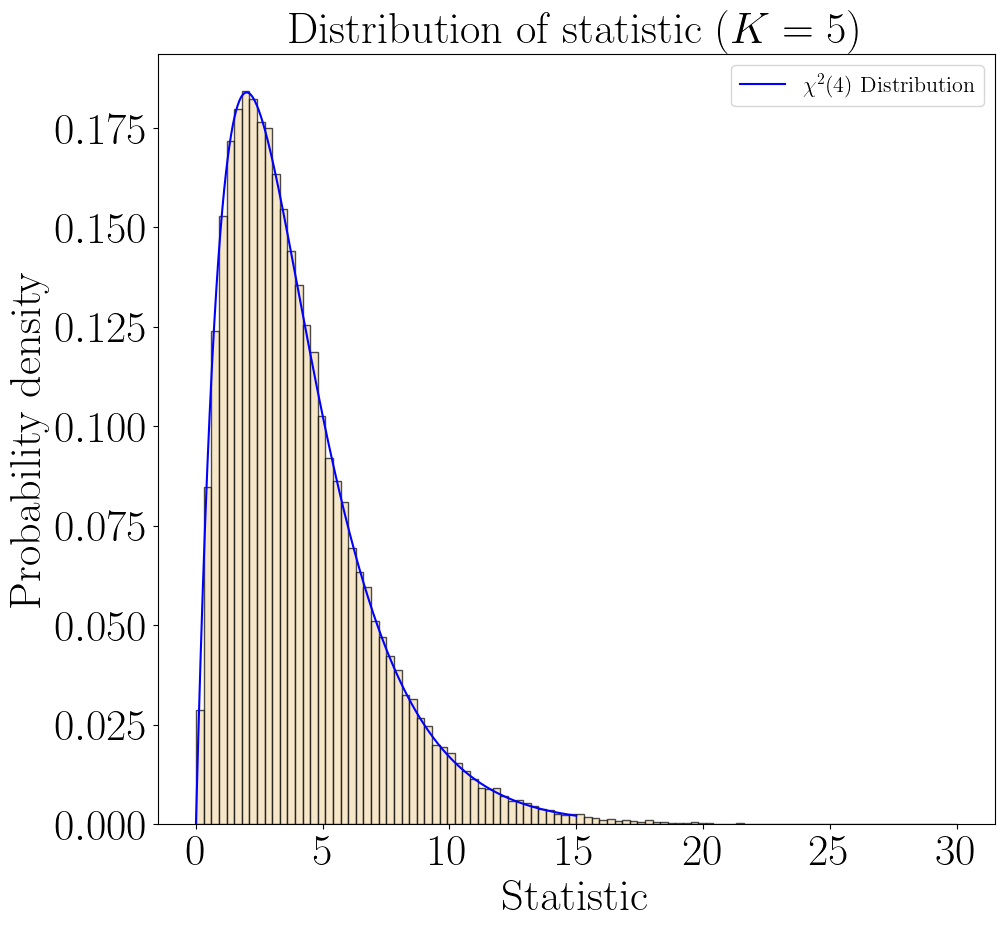

In [5]:
plt.figure(figsize=(10.8, 10))
x = np.linspace(0,3*num, 1000)
pdf = chi2.pdf(x, num-1)
plt.hist(statistics, bins=100, alpha=0.7, color='wheat', edgecolor='black',density = True)
plt.plot(x, pdf, label=fr'$\chi^2({num-1})$ Distribution', color='blue')
plt.title(fr"Distribution of statistic ($K={num}$)",size =sz)
plt.xlabel('Statistic',size =sz)
plt.ylabel('Probability density',size =sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+file_name_1+f'({num}).pdf')

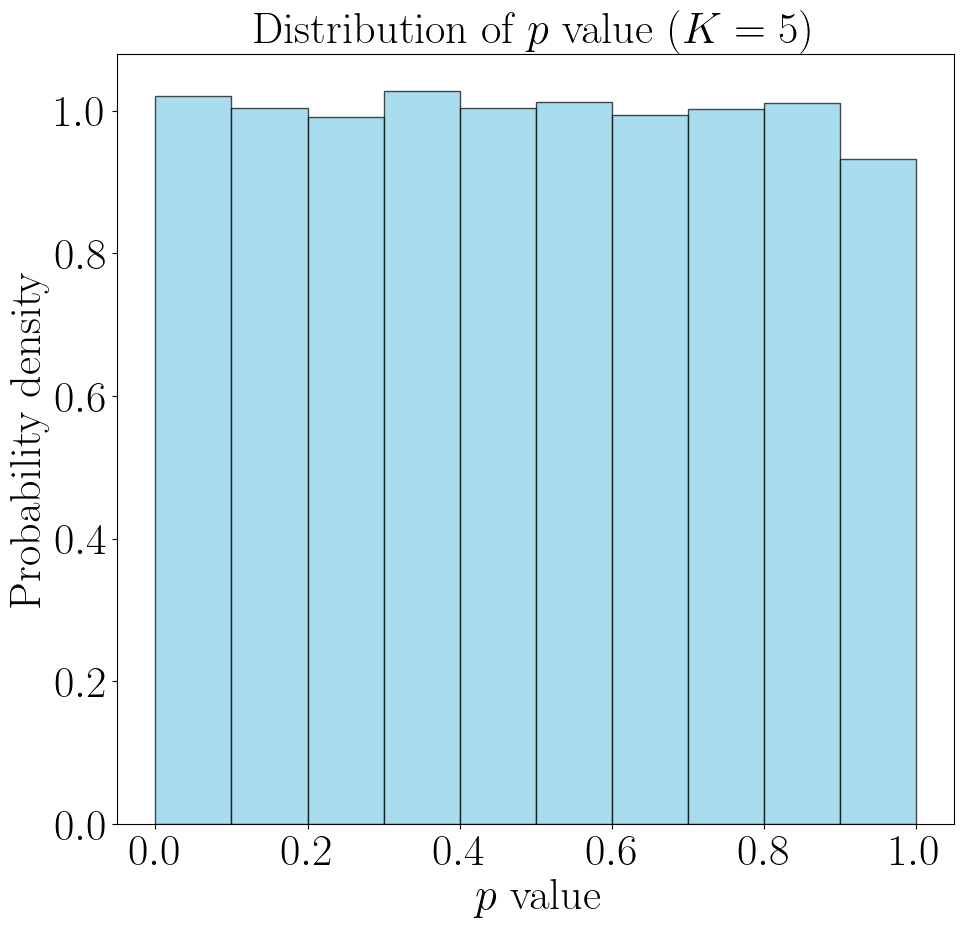

In [6]:
plt.figure(figsize=(10.8, 10))
plt.hist(p_value, bins=10, alpha=0.7, color='skyblue', edgecolor='black',density = True)
plt.title(fr"Distribution of $p$ value ($K={num}$)",size =sz)
plt.xlabel(r'$p$ value',size=sz)
plt.ylabel('Probability density',size=sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.savefig(save_path+file_name_2+f'({num}).pdf')